<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Abbate_et_al.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga del Modelo entrenado

In [1]:
!wget https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip

--2025-06-25 14:49:58--  https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 227385399 (217M) [application/octet-stream]
Saving to: ‘EfficientNetV2S Trained Model Weights.zip’

EfficientNetV2S Tra 100%[===================>] 216.85M  2.14MB/s    in 5m 44s  

2025-06-25 14:55:43 (646 KB/s) - ‘EfficientNetV2S Trained Model Weights.zip’ saved [227385399/227385399]



In [2]:
!unzip "/content/EfficientNetV2S Trained Model Weights.zip"

Archive:  /content/EfficientNetV2S Trained Model Weights.zip
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/assets/
 extracting: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/fingerprint.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/keras_metadata.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/saved_model.pb  
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.data-00000-of-00001  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.index  


In [3]:
!wget https://zenodo.org/records/15565400/files/Replication%20Data.zip

--2025-06-25 14:55:46--  https://zenodo.org/records/15565400/files/Replication%20Data.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 852640867 (813M) [application/octet-stream]
Saving to: ‘Replication Data.zip’

Replication Data.zi 100%[===================>] 813.14M  2.13MB/s    in 6m 18s  

2025-06-25 15:02:05 (2.15 MB/s) - ‘Replication Data.zip’ saved [852640867/852640867]



In [4]:
!unzip "/content/Replication Data.zip"

Archive:  /content/Replication Data.zip
   creating: Replication Data/
  inflating: Replication Data/ARG_2010_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2013_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2018_EPHC-S2_v01_M_v05_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2022_EPHC-S2_v01_M_v01_A_SEDLAC-03_all.dta  
  inflating: Replication Data/censo2010_fullraw_p.dta  
  inflating: Replication Data/deciles_2010.xlsx  
 extracting: Replication Data/income_estimates_2013.cpg  
  inflating: Replication Data/income_estimates_2013.dbf  
  inflating: Replication Data/income_estimates_2013.prj  
  inflating: Replication Data/income_estimates_2013.shp  
  inflating: Replication Data/income_estimates_2013.shx  
 extracting: Replication Data/income_estimates_2018.cpg  
  inflating: Replication Data/income_estimates_2018.dbf  
  inflating: Replication Data/income_estimates_2018.prj  
  inflating: Replication Data/income_estima

In [5]:
from keras.layers import TFSMLayer

# Ruta al directorio que contiene el modelo, no al archivo `.pb`
model_path = '/content/effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/'

# Cargar el modelo como capa inferencial
layer = TFSMLayer(model_path, call_endpoint='serving_default')

# Nueva imagen con Sentinel-2

In [ ]:
!pip install earthengine-api --quiet

import ee
ee.Authenticate()
ee.Initialize(project='sanguine-healer-331000')

In [ ]:
import ee

# Punto de interés
point = ee.Geometry.Point([-58.45, -34.6])

# Parche de 300 m x 300 m
aoi_300m = point.buffer(1500).bounds()

# Selección de imagen Sentinel-2 con baja nubosidad
s2 = (ee.ImageCollection('COPERNICUS/S2_SR')
      .filterBounds(point)
      .filterDate('2022-01-01', '2022-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
      .sort('CLOUDY_PIXEL_PERCENTAGE')
      .first())

# Selección de bandas RGB
rgb_image = s2.select(['B4', 'B3', 'B2']).toFloat()

# Exportar imagen a Google Drive
task = ee.batch.Export.image.toDrive(
    image=rgb_image,
    description='patch_300m_sentinel2_rgb',
    folder='earthengine',
    fileNamePrefix='patch_300m_sentinel2_rgb',
    region=aoi_300m,
    scale=10,  # 10 m/píxel
    crs='EPSG:4326',
    maxPixels=1e8
)

task.start()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio

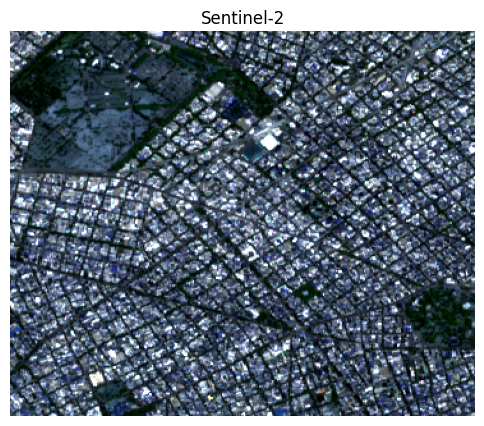

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

img_path = '/content/drive/MyDrive/earthengine/patch_300m_sentinel2_rgb.tif'

with rasterio.open(img_path) as src:
    img = src.read()

# Seleccionar bandas RGB (Bandas 4-3-2 → índices 3,2,1)
r = img[3 - 1].astype(np.float32)
g = img[2 - 1].astype(np.float32)
b = img[1 - 1].astype(np.float32)

# Apilar en eje de color
rgb = np.stack([r, g, b], axis=-1)

# Normalización usando percentiles
p2, p98 = np.percentile(rgb, (2, 98))
rgb_norm = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Mostrar
plt.figure(figsize=(6,6))
plt.imshow(rgb_norm)
plt.axis('off')
plt.title('Sentinel-2')
plt.show()

# Nueva imagen scrapeada

In [6]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
path = kagglehub.dataset_download("leonardocaravaggio/ge-images7")

100%|██████████| 18.5G/18.5G [11:17<00:00, 29.3MB/s]

Extracting files...


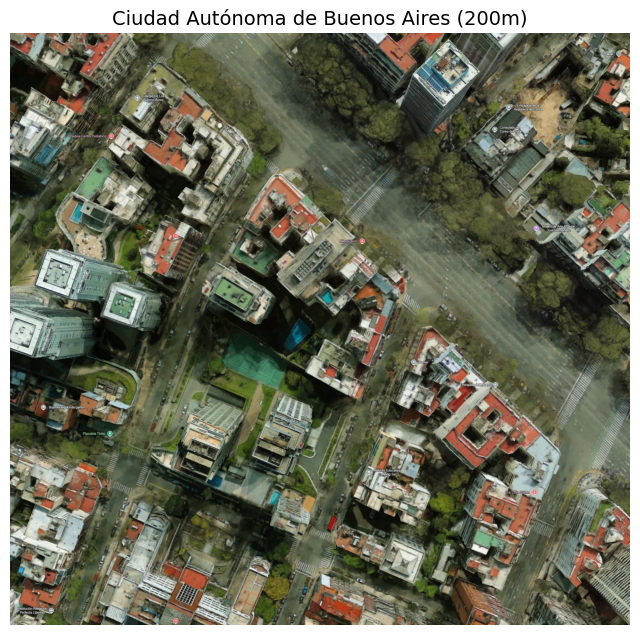

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Simulación de nombre de archivo (asegurate que `ciudades.Nombre_Aglomerado[i]` esté definido)
nombre_aglomerado = "Ciudad Autónoma de Buenos Aires"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_200m = ruta_completa + " 50 - 200m.png"

# Cargar imagen
img = mpimg.imread(img_200m)

# Mostrar imagen
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(nombre_aglomerado + ' (200m)', fontsize=14)
plt.show()

In [8]:
import matplotlib.image as mpimg

# Cargar imagen
img = mpimg.imread(img_200m)

# Obtener dimensiones
alto, ancho = img.shape[:2]
pixeles_totales = alto * ancho

# Definir ancho real en metros (1 km)
ancho_metros = 1_000  # 1 km

# Calcular resolución espacial (m/píxel)
resolucion_m_por_pixel = ancho_metros / ancho

# Mostrar resultados
print(f"Dimensiones: {ancho} x {alto} píxeles")
print(f"Total de píxeles: {pixeles_totales:,}")
print(f"Resolución espacial: {resolucion_m_por_pixel:.2f} metros por píxel")

Dimensiones: 2904 x 2773 píxeles
Total de píxeles: 8,052,792
Resolución espacial: 0.34 metros por píxel


In [9]:
import pandas as pd
ciudades=pd.read_csv("Gini_EPH.csv")

In [10]:
import os
from PIL import Image
import glob
from tqdm import tqdm

# Ruta con las imágenes
ruta_imagenes = path  # Ajustá si es distinto

# Buscar todas las imágenes .png con patrón
archivos_png = glob.glob(os.path.join(ruta_imagenes, "* - *.png"))

for archivo in tqdm(archivos_png, desc="Recortando imágenes"):
    try:
        with Image.open(archivo) as img:
            img.load()  # Forzar carga en memoria
            w, h = img.size
            if w == 2904 and h == 2773:
                margen = (w - 2773) // 2
                img_cortada = img.crop((margen, 0, margen + 2773, 2773))
                img_cortada.save(archivo)
    except Exception as e:
        print(f"Error en {archivo}: {e}")

Recortando imágenes: 100%|██████████| 2416/2416 [2:35:08<00:00,  3.85s/it]


# Inferencia

In [11]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 44.8 MB/s eta 0:00:00


## Inferencia de una imagen

In [12]:
import torch.nn as nn
import torch.optim as optim

# U-Net simplificado
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [51]:
import numpy as np
import matplotlib.image as mpimg
from skimage.transform import resize
import tensorflow as tf
import torch


# Función corregida para cargar y redimensionar la imagen a tamaño fijo
def process_image(img_path, target_size=128):
    """Carga una imagen PNG RGB y la redimensiona a (target_size, target_size, 3)"""
    img = mpimg.imread(img_path).astype(np.float32)

    # Eliminar canal alfa si existe
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    # Redimensionar a tamaño fijo
    img_resized = resize(img, (target_size, target_size, 3),
                         preserve_range=True, anti_aliasing=True).astype(np.float32)
    return img_resized

# Función para generar banda NIR usando modelo PyTorch
def generar_nir_desde_rgb(patch_rgb, model, device):
    """Recibe imagen RGB (H,W,3) y devuelve banda NIR normalizada (H,W)."""
    tensor_rgb = torch.from_numpy(patch_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred_nir = model(tensor_rgb).squeeze().cpu().numpy()
    return pred_nir

In [56]:
import os
import numpy as np
import matplotlib.image as mpimg
from skimage.transform import resize
import torch
import tensorflow as tf

# Parámetros
factor = 4  # no usado directamente en esta versión de process_image
patch_size = 128

nombre_aglomerado = "Gran La Plata"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_50m = ruta_completa + " 50 - 50m.png"
img_200m = ruta_completa + " 50 - 200m.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetGenerator().to(device)
model.load_state_dict(torch.load("unet_rgb2nir.pth", map_location=device))
model.eval()

# Procesar imágenes con tamaño fijo 128x128x3
patch_50m = process_image(img_50m, target_size=patch_size)
patch_200m = process_image(img_200m, target_size=patch_size)

# Predecir NIR para ambas imágenes (128x128)
nir_50m = generar_nir_desde_rgb(patch_50m, model, device)
nir_200m = generar_nir_desde_rgb(patch_200m, model, device)

# Construir parche con 8 canales (128, 128, 8)
parche_8 = np.zeros((patch_size, patch_size, 8), dtype=np.float32)

# Canales 0,1,2 = patch_50m RGB
parche_8[:, :, 0:3] = patch_50m
# Canal 3 = NIR generado a partir de patch_50m
parche_8[:, :, 3] = nir_50m

# Canales 4,5,6 = patch_200m RGB
parche_8[:, :, 4:7] = patch_200m
# Canal 7 = NIR generado a partir de patch_200m
parche_8[:, :, 7] = nir_200m

# Asegurar que no haya NaNs
parche_8 = np.nan_to_num(parche_8, nan=0.0)

# Inferencia (usar el layer TF cargado previamente)
input_tensor = tf.convert_to_tensor(parche_8[np.newaxis, ...], dtype=tf.float32)  # (1,128,128,8)
raw_output = layer(input_tensor, training=False)

# Obtener predicción
if isinstance(raw_output, dict):
    preds = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
else:
    preds = raw_output.numpy().squeeze()

print(f"Predicción del modelo: {preds:.4f}")


Predicción del modelo: -1.0266


## Gini

In [ ]:
import pandas as pd
ciudades=pd.read_csv("Gini_EPH.csv")

In [ ]:
def gini(array):
    array = np.array(array, dtype=np.float32)
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 1e-8
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

In [57]:
from tqdm import tqdm

ginis = []

for i in tqdm(range(len(ciudades)), desc="Procesando ciudades"):
    nombre_aglomerado = ciudades.loc[i, "Nombre_Aglomerado"]
    nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")

    # Listar todos los archivos en el path
    archivos = os.listdir(path)

    # Filtrar archivos que corresponden a este aglomerado y que terminan en - 50m.png o - 200m.png
    imgs_50m = [f for f in archivos if f.startswith(nombre_archivo) and f.endswith(" - 50m.png")]
    imgs_200m = [f for f in archivos if f.startswith(nombre_archivo) and f.endswith(" - 200m.png")]

    # Extraer índices de las imágenes (asumiendo que el formato es: "<nombre> XX - 50m.png")
    # La posición del índice es la penúltima parte al separar por espacios
    def extraer_indice(nombre_archivo_imagen):
        parts = nombre_archivo_imagen.split(" ")
        # El índice está en parts[-3], que debería ser tipo "01", "02", ...
        return parts[-3]

    indices_50m = set(extraer_indice(f) for f in imgs_50m)
    indices_200m = set(extraer_indice(f) for f in imgs_200m)

    # Mantener solo índices comunes
    indices_validos = sorted(indices_50m.intersection(indices_200m))

    preds = []

    for idx in indices_validos:
        try:
            img_50m_path = os.path.join(path, f"{nombre_archivo} {idx} - 50m.png")
            img_200m_path = os.path.join(path, f"{nombre_archivo} {idx} - 200m.png")

            patch_50m = process_image(img_50m_path, target_size=patch_size)
            patch_200m = process_image(img_200m_path, target_size=patch_size)

            nir_50m = generar_nir_desde_rgb(patch_50m, model, device)
            nir_200m = generar_nir_desde_rgb(patch_200m, model, device)

            parche_8 = np.zeros((patch_size, patch_size, 8), dtype=np.float32)
            parche_8[:, :, 0:3] = patch_50m
            parche_8[:, :, 3] = nir_50m
            parche_8[:, :, 4:7] = patch_200m
            parche_8[:, :, 7] = nir_200m

            parche_8 = np.nan_to_num(parche_8, nan=0.0)
            input_tensor = tf.convert_to_tensor(parche_8[np.newaxis, ...], dtype=tf.float32)

            raw_output = layer(input_tensor, training=False)

            if isinstance(raw_output, dict):
                pred = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
            else:
                pred = raw_output.numpy().squeeze()

            preds.append(pred)

        except Exception as e:
            print(f"Error en {nombre_archivo} índice {idx}: {e}")
            continue

    if len(preds) > 0:
        gini_val = gini(preds)
    else:
        gini_val = np.nan

    ginis.append(gini_val)

ciudades["Desigualdad_Modelo"] = ginis


Procesando ciudades: 100%|██████████| 32/32 [2:18:25<00:00, 259.53s/it]


In [34]:
cantidad_imagenes = []

for i in range(len(ciudades)):
    nombre_aglomerado = ciudades.loc[i, "Nombre_Aglomerado"]
    nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")

    archivos = os.listdir(path)

    imgs_50m = [f for f in archivos if f.startswith(nombre_archivo) and " - 50m.png" in f]
    imgs_200m = [f for f in archivos if f.startswith(nombre_archivo) and " - 200m.png" in f]

    # Extraer índices numéricos
    indices_50m = set()
    for f in imgs_50m:
        try:
            idx = int(f.split(" ")[-3])
            indices_50m.add(idx)
        except:
            continue

    indices_200m = set()
    for f in imgs_200m:
        try:
            idx = int(f.split(" ")[-3])
            indices_200m.add(idx)
        except:
            continue

    # Solo contar los índices que tienen imagen en ambas resoluciones
    pares_validos = indices_50m.intersection(indices_200m)
    cantidad_imagenes.append(len(pares_validos))

# Agregar al DataFrame
ciudades["Cantidad_Imagenes"] = cantidad_imagenes


In [58]:
ciudades

,Unnamed: 0,AGLOMERADO,Nombre_Aglomerado,Gini_Personas,Gini_Hogares,Desigualdad_Modelo,Cantidad_Imagenes
0,0,2,Gran La Plata,0.477884,0.430569,0.248167,50
1,25,32,Ciudad Autónoma de Buenos Aires,0.405170,0.415689,0.272348,50
2,23,30,Santa Rosa-Toay,0.435322,0.413948,0.260249,50
3,8,10,Gran Mendoza,0.414483,0.404377,NaN,0
4,26,33,Partidos del Gran Buenos Aires,0.430662,0.397060,0.179437,50
5,28,36,Río Cuarto,0.450962,0.391219,NaN,0
6,24,31,Ushuaia-Río Grande,0.447865,0.384391,0.297988,50
7,13,17,Neuquén-Plottier,0.384695,0.382769,0.312659,50
8,18,23,Gran Salta,0.389239,0.381227,NaN,0
9,3,5,Gran Santa Fe,0.415640,0.378615,0.232876,50


In [59]:
from scipy.stats import pearsonr

# Filtrar ciudades con exactamente 50 imágenes y sin NaNs
df_filtrado = ciudades[(ciudades["Cantidad_Imagenes"] == 50)]

x = df_filtrado["Desigualdad_Modelo"]
y = df_filtrado["Gini_Hogares"]
mask = x.notna() & y.notna()

# Calcular correlación de Pearson
r, p = pearsonr(x[mask], y[mask])

print(f"Coeficiente de Pearson: {r:.3f}")
print(f"Valor p: {p:.5f}")


Coeficiente de Pearson: -0.118
Valor p: 0.61020


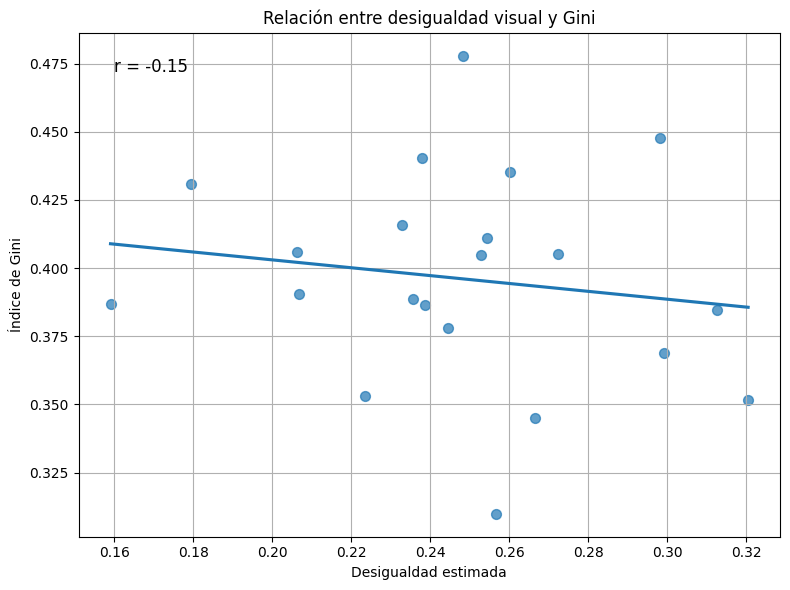

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filtrar datos válidos
x = df_filtrado["Desigualdad_Modelo"]
y = df_filtrado["Gini_Personas"]
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

# Calcular correlación
r, p = pearsonr(x_valid, y_valid)

# Determinar nivel de significancia
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = ""

# Crear gráfico
plt.figure(figsize=(8, 6))
sns.regplot(x=x_valid, y=y_valid, ci=None, scatter_kws={"s": 50, "alpha": 0.7})

# Anotar r y p
plt.text(0.05, 0.95, f"r = {r:.2f}{stars}", ha="left", va="top", transform=plt.gca().transAxes, fontsize=12)

plt.xlabel("Desigualdad estimada")
plt.ylabel("Índice de Gini")
plt.title("Relación entre desigualdad visual y Gini")
plt.grid(True)
plt.tight_layout()
plt.show()